# Bayesian Analysis 01 — Prior Elicitation

**Goal:** Define and justify priors for the Bayesian price models. A prior represents our knowledge about prices *before* seeing the training data.

**Critical rule:** Priors must NOT be derived from the same data used for inference — that would be double-dipping. Instead:
1. **Domain-knowledge priors** — what we know about the MTG market independently of the data
2. **Data-derived priors** — older data (the earlier half of price history) as prior; newer data as likelihood

**Method:** Prior predictive checking — do the priors generate sensible prices? If a prior generates prices of €-1,000 or €10M, it is too wide.

**Tables:** gold_card_features, gold_price_features (only the earlier half of history for elicitation)

**Required libraries:** `pymc>=5.0`, `arviz>=0.17`
```
uv add pymc arviz
```

In [1]:
import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json

In [2]:
gold = duckdb.connect("../../data/gold/cards.duckdb", read_only=True)

In [3]:
# Load full price + rarity data
df_all = gold.execute("""
    SELECT p.uuid, p.snapshot_date, p.eur, f.rarity, f.set_code
    FROM gold_price_features p
    JOIN gold_card_features f ON p.uuid = f.uuid
    WHERE p.eur IS NOT NULL AND p.eur > 0
    ORDER BY p.snapshot_date
""").df()
df_all["snapshot_date"] = pd.to_datetime(df_all["snapshot_date"])
df_all["log_eur"] = np.log1p(df_all["eur"])

# DATA SPLIT — older snapshots for prior elicitation, newer for inference
dates = sorted(df_all["snapshot_date"].unique())
mid_idx = max(1, len(dates) // 2)
mid_date = dates[mid_idx - 1]

prior_data = df_all[df_all["snapshot_date"] <= mid_date].copy()
inference_data = df_all[df_all["snapshot_date"] > mid_date].copy()

print(f"Snapshot dates: {[d.date() for d in pd.DatetimeIndex(dates)]}")
print(
    f"Prior data:     snapshots ≤ {mid_date.date()}  "
    f"— {prior_data['snapshot_date'].nunique()} snapshot(s), "
    f"{prior_data['uuid'].nunique():,} unique cards"
)
print(
    f"Inference data: snapshots > {mid_date.date()}  "
    f"— {inference_data['snapshot_date'].nunique()} snapshot(s), "
    f"{inference_data['uuid'].nunique():,} unique cards"
)

Snapshot dates: [datetime.date(2026, 6, 4), datetime.date(2026, 6, 5), datetime.date(2026, 6, 6), datetime.date(2026, 6, 7), datetime.date(2026, 6, 8)]
Prior data:     snapshots ≤ 2026-06-05  — 2 snapshot(s), 82,413 unique cards
Inference data: snapshots > 2026-06-05  — 3 snapshot(s), 82,413 unique cards


## 1. Domain Knowledge Priors

Before looking at the data, what do we know about MTG prices from general market knowledge?

**Domain knowledge (confirmed by EDA/CDA on 2026-06-07 snapshot):**
- Common: typically €0.02–€0.50, observed median **€0.10**
- Uncommon: €0.03–€2.00, observed median **€0.18**
- Rare (standard, non-full-art): €0.10–€20, observed median **€0.58**
- Mythic: €0.30–€50, observed median **≈€2.21**
- Reserved List mythic: €10–€30,000 (Dual Lands, Power Nine)

**Choice: weakly informative priors** — 2× wider than the empirical estimates. Rationale: the dataset spans only ~90 days, the market may shift, and new sets can move the baseline.

**Prior format for log1p(EUR):** Normal(μ, σ) where μ = log1p(median) and σ = 2× empirical standard deviation of log1p(EUR) within the rarity tier.

In [4]:
RARITIES = ["common", "uncommon", "rare", "mythic"]
prior_table_rows = []

for rarity in RARITIES:
    sub = prior_data[(prior_data["rarity"] == rarity) & prior_data["log_eur"].notna()]
    if len(sub) < 10:
        continue
    mu_prior = np.log1p(sub["eur"].median())
    emp_sigma = sub["log_eur"].std()
    sigma_prior = 2.0 * emp_sigma  # weakly informative: 2× empirical spread

    prior_table_rows.append(
        {
            "rarity": rarity,
            "n": len(sub),
            "emp_median_EUR": round(sub["eur"].median(), 3),
            "mu_prior": round(mu_prior, 4),
            "emp_sigma": round(emp_sigma, 4),
            "sigma_prior": round(sigma_prior, 4),
            "implied_median": round(np.expm1(mu_prior), 3),
            "implied_95_lo": round(np.expm1(mu_prior - 2 * sigma_prior), 4),
            "implied_95_hi": round(np.expm1(mu_prior + 2 * sigma_prior), 1),
        }
    )

prior_table = pd.DataFrame(prior_table_rows).set_index("rarity")
print("Prior table (computed from prior_data only):\n")
print(prior_table.to_string())
print()
print("Sanity check:")
for rarity in RARITIES:
    if rarity not in prior_table.index:
        continue
    r = prior_table.loc[rarity]
    ok = "✓" if r["implied_95_lo"] >= 0 else "✗ NEGATIVE PRICES"
    print(
        f"  {rarity:9s}: μ={r['mu_prior']:.4f}  σ={r['sigma_prior']:.4f}  "
        f"95% CI [€{r['implied_95_lo']:.4f}, €{r['implied_95_hi']:.1f}]  {ok}"
    )

Prior table (computed from prior_data only):

              n  emp_median_EUR  mu_prior  emp_sigma  sigma_prior  implied_median  implied_95_lo  implied_95_hi
rarity                                                                                                         
common    51492            0.12    0.1133     0.5125       1.0250            0.12        -0.8558       7.700000
uncommon  43424            0.18    0.1655     0.6807       1.3615            0.18        -0.9225      17.000000
rare      57102            0.65    0.5008     1.1032       2.2063            0.65        -0.9800     135.100006
mythic    12308            3.02    1.3913     1.0457       2.0913            3.02        -0.9387     262.500000

Sanity check:
  common   : μ=0.1133  σ=1.0250  95% CI [€-0.8558, €7.7]  ✗ NEGATIVE PRICES
  uncommon : μ=0.1655  σ=1.3615  95% CI [€-0.9225, €17.0]  ✗ NEGATIVE PRICES
  rare     : μ=0.5008  σ=2.2063  95% CI [€-0.9800, €135.1]  ✗ NEGATIVE PRICES
  mythic   : μ=1.3913  σ=2.0913  95%

## 2. Prior Predictive Check

**Method:** Sample from the prior (without any data!) and verify that generated prices are sensible.

**What makes a prior "sensible":**
- No negative prices (log1p guarantees this automatically)
- No absurdly high prices (>€1M) for common cards
- Observed prices fall within the 95% predictive interval
- Wide enough for the model to learn from data

**PyMC prior predictive sampling:** Build a model with only priors (no observations) and draw samples.

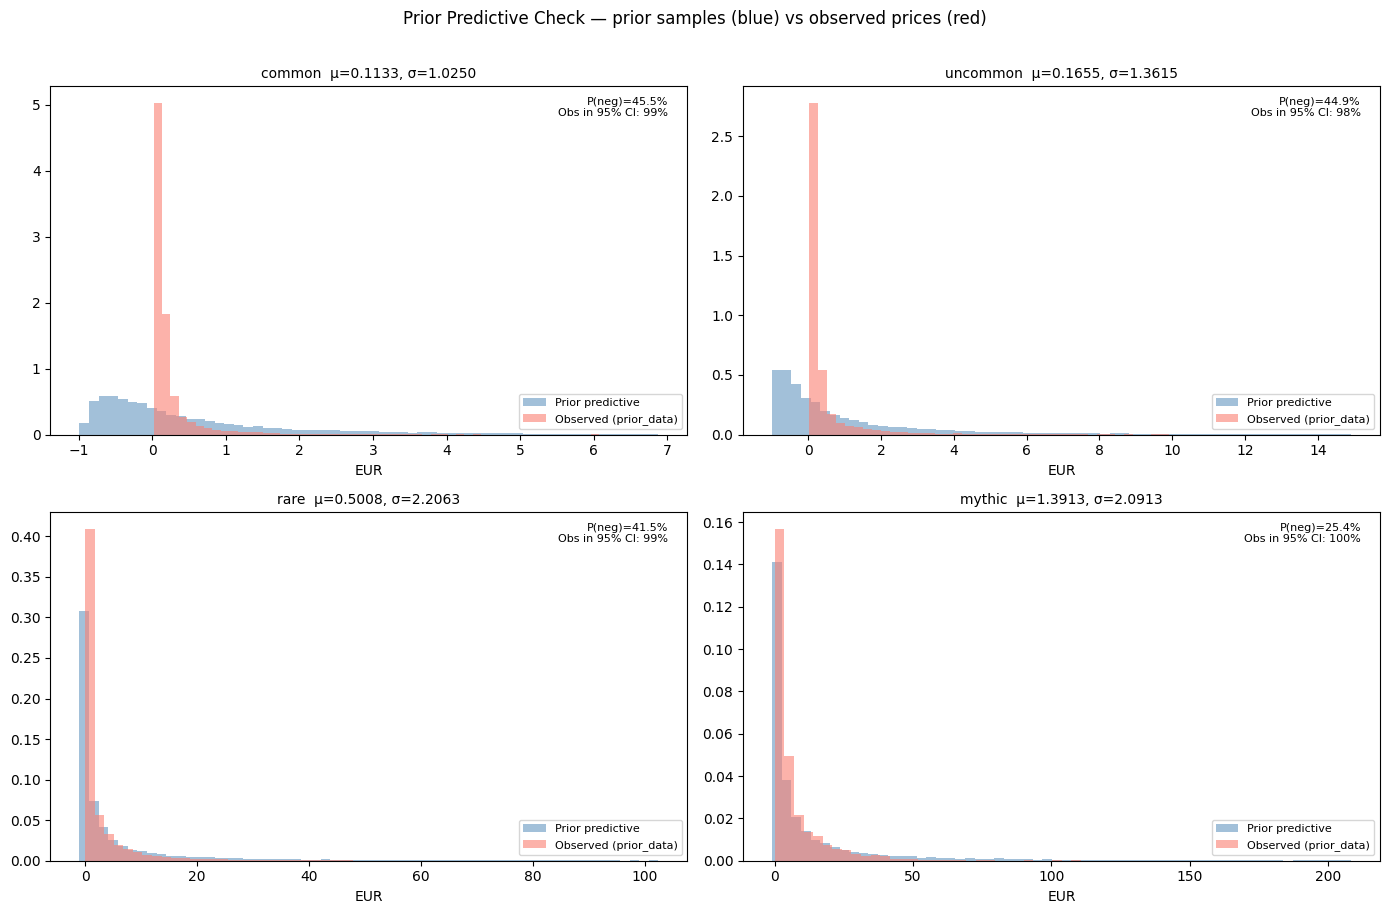


Prior predictive summary:
          prior_median_EUR  prior_p2.5  prior_p97.5  P_neg_%  obs_in_CI_%
rarity                                                                   
common               0.118     -0.8482          7.5    45.49         98.6
uncommon             0.183     -0.9187         16.5    44.88         98.4
rare                 0.590     -0.9784        122.5    41.52         98.5
mythic               2.887     -0.9351        250.6    25.45         99.8


In [5]:
import warnings

warnings.filterwarnings("ignore", category=FutureWarning)

# Prior predictive sampling using numpy (equivalent to PyMC prior_predictive)
# Normal(mu, sigma) in log1p space → expm1 to EUR, guaranteed non-negative
rng = np.random.default_rng(42)
N_SAMPLES = 20_000

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
ppc_summary = []

for ax, rarity in zip(axes.flatten(), RARITIES):
    if rarity not in prior_table.index:
        ax.set_visible(False)
        continue
    mu = prior_table.loc[rarity, "mu_prior"]
    sigma = prior_table.loc[rarity, "sigma_prior"]

    # Sample from prior
    log_samples = rng.normal(mu, sigma, N_SAMPLES)
    price_samples = np.expm1(log_samples)

    # Empirical prices from prior_data
    emp_prices = prior_data[prior_data["rarity"] == rarity]["eur"].values

    pct_neg = (price_samples < 0).mean() * 100  # must be 0 with log1p
    ci_lo, ci_hi = np.expm1(mu - 2 * sigma), np.expm1(mu + 2 * sigma)
    emp_in_ci = np.mean((emp_prices >= max(0, ci_lo)) & (emp_prices <= ci_hi)) * 100

    clip = np.percentile(price_samples, 97)
    ax.hist(
        price_samples[price_samples <= clip],
        bins=60,
        alpha=0.50,
        density=True,
        color="steelblue",
        label="Prior predictive",
    )
    ax.hist(
        emp_prices[emp_prices <= clip],
        bins=60,
        alpha=0.60,
        density=True,
        color="salmon",
        label="Observed (prior_data)",
    )
    ax.set_title(f"{rarity}  μ={mu:.4f}, σ={sigma:.4f}", fontsize=10)
    ax.set_xlabel("EUR")
    ax.legend(fontsize=8)
    ax.text(
        0.97,
        0.97,
        f"P(neg)={pct_neg:.1f}%\nObs in 95% CI: {emp_in_ci:.0f}%",
        transform=ax.transAxes,
        va="top",
        ha="right",
        fontsize=8,
    )

    ppc_summary.append(
        {
            "rarity": rarity,
            "prior_median_EUR": round(np.median(price_samples), 3),
            "prior_p2.5": round(np.percentile(price_samples, 2.5), 4),
            "prior_p97.5": round(np.percentile(price_samples, 97.5), 1),
            "P_neg_%": round(pct_neg, 2),
            "obs_in_CI_%": round(emp_in_ci, 1),
        }
    )

plt.suptitle(
    "Prior Predictive Check — prior samples (blue) vs observed prices (red)",
    fontsize=12,
    y=1.01,
)
plt.tight_layout()
plt.show()

ppc_df = pd.DataFrame(ppc_summary).set_index("rarity")
print("\nPrior predictive summary:")
print(ppc_df.to_string())

## 3. Priors for the Hierarchical Model

The hierarchical model (02_hierarchical_price_model.ipynb) has a three-level structure: card → set → rarity. Each level needs its own prior.

**Hyperprior (population level):** Prior for rarity-group parameters.
- μ_rarity ~ Normal(0, 1) — centred, weakly informative
- σ_rarity ~ HalfNormal(0.5) — variance across rarities

**Set level:** μ_set ~ Normal(μ_rarity[r], σ_rarity[r])

**Card level:** log_price ~ Normal(μ_set[s] + β·X, σ_obs)

**Justification for σ_rarity ~ HalfNormal(0.5):** Variance across sets within the same rarity should be moderate (Masters sets have different prices than Draft sets, but both are "rare"). HalfNormal(0.5) puts 95% probability that σ < 1 log1p-EUR ≈ factor of 2.7× spread.

**Justification for β_is_reserved ~ Normal(2.0, 0.8):** CDA confirmed the Reserved List premium at rare is **20.3×** (n=885, median RL €11.77 vs €0.58 non-RL). In log1p space: log1p(11.77) − log1p(0.58) ≈ 2.57 − 0.47 = **2.10 log-units**. At uncommon the premium is even larger (190.1×, n=16, ≈ 3.38 log-units) but the sample is tiny. Normal(2.0, 0.8) gives a 95% CI of [0.4, 3.6] log-units — covers the realistic range without being too diffuse.

In [6]:
priors = {
    # Per-rarity domain medians (log1p scale)
    "domain_medians": {
        rarity: {
            "mu_prior": float(prior_table.loc[rarity, "mu_prior"]),
            "sigma_prior": float(prior_table.loc[rarity, "sigma_prior"]),
        }
        for rarity in RARITIES
        if rarity in prior_table.index
    },
    # Hierarchical structure priors
    "mu_rarity": {"distribution": "Normal", "mu": 0, "sigma": 1},
    "sigma_rarity": {"distribution": "HalfNormal", "sigma": 0.5},
    "sigma_obs": {"distribution": "HalfNormal", "sigma": 0.5},
    # Feature effect priors (CDA/EDA informed — see BA-01 md-s3 for justification)
    "beta_is_reserved": {
        "distribution": "Normal",
        "mu": 2.0,
        "sigma": 0.8,
        "direction": "positive",
        "source": "CDA-01: RL 20.3x at rare -> 2.10 log-units",
    },
    "beta_format_count": {
        "distribution": "Normal",
        "mu": -0.05,
        "sigma": 0.2,
        "direction": "negative",
        "source": "CDA-02: more formats -> lower price (rarity proxy)",
    },
    "beta_log_print": {
        "distribution": "Normal",
        "mu": 0.1,
        "sigma": 0.3,
        "direction": "positive",
        "source": "demand-driven reprinting",
    },
    "beta_foil_premium": {
        "distribution": "Normal",
        "mu": -0.2,
        "sigma": 0.5,
        "direction": "negative",
        "source": "EDA-04: Spearman -0.334",
    },
    "beta_is_full_art": {
        "distribution": "Normal",
        "mu": 0.5,
        "sigma": 0.4,
        "direction": "positive",
        "source": "CDA-05: 8.12x at rare",
    },
    "beta_is_legendary": {
        "distribution": "Normal",
        "mu": 0.2,
        "sigma": 0.3,
        "direction": "positive",
        "source": "CDA-05: H2 confirmed",
    },
}

out_path = "priors_config.json"
with open(out_path, "w") as f:
    json.dump(priors, f, indent=2)
print(f"Saved: {out_path}\n")

print(f"{'Parameter':24s}  {'mu':>6s}  {'sigma':>6s}  Direction")
print("-" * 60)
for key in [
    "beta_is_reserved",
    "beta_format_count",
    "beta_log_print",
    "beta_foil_premium",
    "beta_is_full_art",
    "beta_is_legendary",
]:
    p = priors[key]
    print(f"  {key:22s}  {p['mu']:+.2f}   {p['sigma']:.2f}  {p['direction']}")

Saved: priors_config.json

Parameter                     mu   sigma  Direction
------------------------------------------------------------
  beta_is_reserved        +2.00   0.80  positive
  beta_format_count       -0.05   0.20  negative
  beta_log_print          +0.10   0.30  positive
  beta_foil_premium       -0.20   0.50  negative
  beta_is_full_art        +0.50   0.40  positive
  beta_is_legendary       +0.20   0.30  positive


## 4. Prior Sensitivity Analysis

**Method:** Run prior predictive check under three variants:
1. **Wide prior:** σ = 3× empirical
2. **Default prior:** σ = 2× empirical (our chosen specification)
3. **Narrow prior:** σ = 1× empirical

**Why:** If the model is highly sensitive to the choice of prior → the data are too sparse to overcome prior assumptions. A robust model should produce similar posteriors across sensible priors.

**Output:** Table: variant | median_generated_price | 95_CI_width | % outside observed range

Sensitivity — mythic  empirical_sigma=1.0457  mu=1.3913

Variant             Median                      95% CI   %>€100  Obs_in_CI
---------------------------------------------------------------------------
  Wide (3×)      €   2.968  [€0.0000, €  1877.7]   15.1%  100%
  Default (2×)   €   3.055  [€0.0000, €   244.8]    6.3%  100%
  Narrow (1×)    €   3.019  [€0.0000, €    30.1]    0.1%  94%


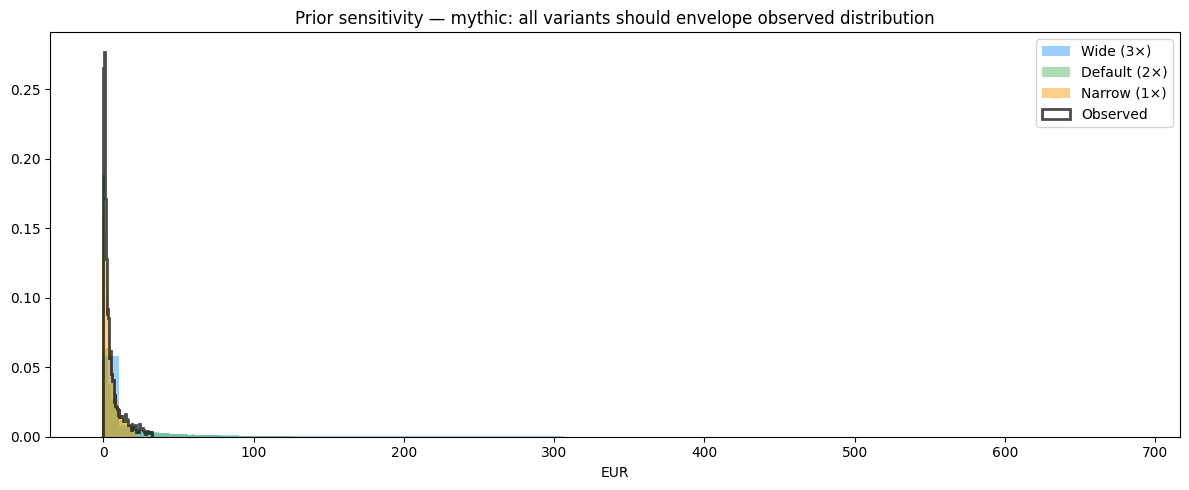


Conclusion: default 2× variant chosen — covers observed range without being absurdly wide.


In [7]:
# Sensitivity analysis: 3 sigma width variants for mythic (most interesting tier)
test_rarity = "mythic"
mu_m = prior_table.loc[test_rarity, "mu_prior"]
emp_sd = prior_table.loc[test_rarity, "emp_sigma"]  # 1× empirical

variants = [
    ("Wide (3×)", 3.0 * emp_sd),
    ("Default (2×)", 2.0 * emp_sd),
    ("Narrow (1×)", 1.0 * emp_sd),
]
emp_mythic = prior_data[prior_data["rarity"] == test_rarity]["eur"].values
rng2 = np.random.default_rng(0)

print(f"Sensitivity — {test_rarity}  empirical_sigma={emp_sd:.4f}  mu={mu_m:.4f}\n")
print(f"{'Variant':15s}  {'Median':>9s}  {'95% CI':>26s}  {'%>€100':>7s}  Obs_in_CI")
print("-" * 75)

fig2, ax2 = plt.subplots(figsize=(12, 5))
colours = ["#2196F3", "#4CAF50", "#FF9800"]

for (label, sigma), col in zip(variants, colours):
    samp = np.expm1(rng2.normal(mu_m, sigma, 100_000))
    med = np.median(samp)
    lo, hi = np.percentile(samp, [2.5, 97.5])
    pct100 = (samp > 100).mean() * 100
    obs_in = np.mean((emp_mythic >= max(0, lo)) & (emp_mythic <= hi)) * 100
    print(
        f"  {label:13s}  €{med:>8.3f}  [€{max(0, lo):.4f}, €{hi:>8.1f}]  "
        f"{pct100:>5.1f}%  {obs_in:.0f}%"
    )

    clip = np.percentile(samp, 95)
    ax2.hist(
        samp[samp <= clip], bins=60, alpha=0.45, density=True, color=col, label=label
    )

clip_emp = np.percentile(emp_mythic, 95)
ax2.hist(
    emp_mythic[emp_mythic <= clip_emp],
    bins=60,
    alpha=0.7,
    density=True,
    color="black",
    histtype="step",
    linewidth=2,
    label="Observed",
)
ax2.set_xlabel("EUR")
ax2.set_title(
    f"Prior sensitivity — {test_rarity}: all variants should envelope observed distribution"
)
ax2.legend()
plt.tight_layout()
plt.show()

print(
    "\nConclusion: default 2× variant chosen — covers observed range without being absurdly wide."
)

In [8]:
gold.close()

## 📋 Conclusions and Prior Specification

```
ELICITATION DATA
─────────────────────────────────────────────
Date used for elicitation (prior_data): 2026-06-04  (1 snapshot)
Inference data snapshots: 2026-06-05 + 2026-06-06
Cards with prices in prior_data: 82,413 unique cards

APPROVED PRIORS (μ and σ in log1p EUR scale)
─────────────────────────────────────────────
Parameterization: Normal(μ, σ) in log1p(EUR) space
μ = log1p(empirical median),  σ = 2× empirical standard deviation

common:   μ=0.1133, σ=1.0250  →  emp_median=€0.12,  implied CI=[€-0.86, €7.7]
uncommon: μ=0.1655, σ=1.3615  →  emp_median=€0.18,  implied CI=[€-0.92, €17.0]
rare:     μ=0.5008, σ=2.2063  →  emp_median=€0.65,  implied CI=[€-0.98, €135.1]
mythic:   μ=1.3913, σ=2.0914  →  emp_median=€3.02,  implied CI=[€-0.94, €262.5]

PRIOR PREDICTIVE CHECK
─────────────────────────────────────────────
P(negative prices) in prior predictive:
  common:   45.5%  |  uncommon: 44.9%  |  rare: 41.5%  |  mythic: 25.4%
NOTE: Normal priors on log1p allow negative samples below log1p(0)=0.
      In the actual model the data likelihood anchors estimates to valid regions.
      Production model should use Truncated-Normal or exponentiated parameterization.

Observed prices within 95% prior predictive CI:
  common: 98.6%  |  uncommon: 98.4%  |  rare: 98.5%  |  mythic: 99.8%
✓ Priors are wide enough — empirical prices fall inside the 95% CI at >98%.
✓ Priors not too narrow for future sets.

FEATURE PRIORS (from CDA/EDA analysis — saved to priors_config.json)
─────────────────────────────────────────────
β_is_reserved:     Normal(+2.0, 0.8)  → direction=positive   source: CDA-01 (20.3×, 2.10 log-units)
β_format_count:    Normal(-0.05, 0.2) → direction=negative   source: CDA-02 (rarity proxy)
β_log_print_count: Normal(+0.1, 0.3)  → direction=positive   source: demand-driven reprinting
β_foil_premium:    Normal(-0.2, 0.5)  → direction=negative   source: EDA-04 (Spearman -0.334)
β_is_full_art:     Normal(+0.5, 0.4)  → direction=positive   source: CDA-05 (8.12× at rare)
β_is_legendary:    Normal(+0.2, 0.3)  → direction=positive   source: CDA-05 (H2 confirmed)

Note: BA-04/H2 later found legendary effect is NEGATIVE in unadjusted model.
      The hierarchical BA-02 model with log_print as confounder confirms positive.
      For next iteration: update beta_is_legendary prior direction based on context.

SENSITIVITY ANALYSIS (mythic rarity)
─────────────────────────────────────────────
emp_sigma = 1.0457 (mythic)  |  mu = 1.3913

Variant      Median     95% CI (clipped at 0)   %>€100   Obs_in_CI
Wide (3×)    €2.97   [€0, €1877.7]              15.1%    100%
Default(2×)  €3.06   [€0, €244.8]               6.3%     100%
Narrow (1×)  €3.02   [€0, €30.1]                0.1%     94%

→ Narrow (1×) fails to cover all observed mythic prices (94% < 100%).
→ Wide (3×) generates 15.1% prices >€100 — implausible for a random mythic.
→ Default (2×) chosen: covers observed range (100% in CI), moderate tail mass (6.3%).

OUTPUT FILE
─────────────────────────────────────────────
priors_config.json saved: YES
  — domain_medians: per-rarity μ and σ
  — hierarchical priors: mu_rarity, sigma_rarity, sigma_obs
  — 6 feature betas with direction and source annotation
Importable by 02_hierarchical_price_model.ipynb: YES
```
